# Show, Attend and Tell — Training, Evaluation & Comparison

Implementation of *"Show, Attend and Tell: Neural Image Caption Generation with Visual Attention"* (Xu et al., 2015).  
Three encoders compared: **VGG19**, **ResNet50**, **CLIP ViT-B/16** — all with the same soft-attention LSTM decoder.  
Dataset: Flickr8k. Training uses bf16 mixed-precision and RMSProp with early stopping on val BLEU-4.

In [1]:
import sys, os
ROOT = os.path.abspath(os.path.join(os.path.dirname('__file__'), '..'))
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)
os.chdir(ROOT)
print('Working dir:', os.getcwd())

import torch
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))
    print('VRAM:', round(torch.cuda.get_device_properties(0).total_memory / 1e9, 1), 'GB')

Working dir: /workspace
Device: cuda
GPU: NVIDIA GeForce RTX 5090
VRAM: 33.7 GB


## 1. Encoder shape smoke-test (fast, no data loading)

In [ ]:
from src.models.encoder import Encoder

x = torch.randn(2, 3, 224, 224).to(device)
for name in ['vgg19', 'resnet50', 'clip_vit_b16']:
    enc = Encoder(name).to(device)
    with torch.no_grad():
        out = enc(x)
    print(f'{name:20s}  output={tuple(out.shape)}  dim={enc.output_dim}')
    assert out.shape == (2, 196, enc.output_dim)
    del enc
torch.cuda.empty_cache()
print('All encoder shapes OK ✓')

## 2. Full Training

Each cell trains one model to convergence via early stopping (patience=7 on val BLEU-4).  
Checkpoints saved to `checkpoints/<encoder_name>/best.pt`.  
W&B logs are stored offline in `wandb/` — run `wandb sync` to upload if desired.

> **Tip:** Run each cell independently. Training takes ~15-30 min per model on the RTX 5090.

In [ ]:
import subprocess

def run_training(encoder_name, extra_args=None):
    """Launch training for an encoder. Streams output live."""
    args = [sys.executable, '-m', 'src.main', 'mode=train', f'encoder={encoder_name}']
    if extra_args:
        args.extend(extra_args)
    print(f'\n=== Training {encoder_name} ===')
    result = subprocess.run(args, cwd=ROOT)
    print(f'=== {encoder_name} finished (exit={result.returncode}) ===')
    return result.returncode == 0

In [ ]:
# Train VGG19 (paper baseline)
run_training('vgg19')

In [ ]:
# Train ResNet50
run_training('resnet50')

In [ ]:
# Train CLIP ViT-B/16
run_training('clip_vit_b16')

## 3. BLEU Evaluation on Test Set

In [2]:
from omegaconf import OmegaConf
from src.eval import evaluate_checkpoint
from pathlib import Path

base_cfg = OmegaConf.load('config/train.yaml')
enc_cfgs = {
    'vgg19':       OmegaConf.load('config/encoder/vgg19.yaml'),
    'resnet50':    OmegaConf.load('config/encoder/resnet50.yaml'),
    'clip_vit_b16': OmegaConf.load('config/encoder/clip_vit_b16.yaml'),
}

results = {}
for enc_name, enc_cfg in enc_cfgs.items():
    ckpt = f'checkpoints/{enc_name}/best.pt'
    if not Path(ckpt).exists():
        print(f'  [{enc_name}] checkpoint not found, skipping.')
        continue
    cfg = OmegaConf.merge(base_cfg, OmegaConf.create({'encoder': enc_cfg}))
    scores = evaluate_checkpoint(ckpt, cfg, device=device)
    results[enc_name] = scores


── Test BLEU  [vgg19] ─────────────────
  BLEU1: 59.7
  BLEU2: 39.1
  BLEU3: 25.7
  BLEU4: 17.0
─────────────────────────────────────────


── Test BLEU  [resnet50] ─────────────────
  BLEU1: 62.9
  BLEU2: 42.1
  BLEU3: 28.3
  BLEU4: 19.0
─────────────────────────────────────────



Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] CLIPVisionModel LOAD REPORT from: openai/clip-vit-base-patch16
Key                                                          | Status     |  | 
-------------------------------------------------------------+------------+--+-
text_model.encoder.layers.{0...11}.layer_norm1.weight        | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.q_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.k_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc2.weight            | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc2.bias              | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc1.bias              | UNEXPECTED |  | 
text_model.final_layer_norm.bias                             | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.out_proj.bias   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.q_proj.weight   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_n


── Test BLEU  [clip_vit_b16] ─────────────────
  BLEU1: 69.2
  BLEU2: 50.1
  BLEU3: 35.9
  BLEU4: 25.8
─────────────────────────────────────────



In [ ]:
import pandas as pd

if results:
    rows = []
    for enc_name, scores in results.items():
        rows.append({
            'Encoder': enc_name,
            'BLEU-1': round(scores['bleu1'] * 100, 1),
            'BLEU-2': round(scores['bleu2'] * 100, 1),
            'BLEU-3': round(scores['bleu3'] * 100, 1),
            'BLEU-4': round(scores['bleu4'] * 100, 1),
        })
    df = pd.DataFrame(rows).set_index('Encoder')
    print('\n=== Test BLEU Comparison ===')
    print(df.to_string())
    print('\nPaper (VGG / Soft Attention): BLEU-1=67.0  BLEU-2=44.8  BLEU-3=29.9  BLEU-4=19.5')
else:
    print('No results yet — train the models first.')

## 4. Attention Visualisation

For each word in a generated caption, show the upsampled 14×14 soft-attention map overlaid on the image (Figure 3/4 of the paper). Shown for all three encoders on the same image.

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import zoom
from PIL import Image
import random

from src.models.model import Model
from src.models.transforms_factory import get_transforms
from src.dataset.AnnotationDataset import AnnotationDataset
from src.dataset.vocabulary import Vocabulary
from src.eval import generate_caption

vocab = Vocabulary.load('data/flicker8k/vocab.json')

def load_model(enc_name):
    ckpt_path = f'checkpoints/{enc_name}/best.pt'
    if not Path(ckpt_path).exists():
        print(f'  Checkpoint not found: {ckpt_path}')
        return None, None
    _, test_tf = get_transforms(enc_name)
    m = Model(device=device, enc_model_name=enc_name,
              max_seq_len=30, dropout_prob=0.0, use_tf=False).to(device)
    ckpt = torch.load(ckpt_path, map_location=device)
    m.load_state_dict(ckpt['model_state'])
    m.eval()
    return m, test_tf

def visualise_attention(img_path, model, transforms, title='', smooth=True):
    raw_img = Image.open(img_path).convert('RGB').resize((224, 224))
    img_tensor = transforms(raw_img)
    caption, attention = generate_caption(model, img_tensor, device)
    words = caption.split()
    if not words:
        return
    ncols = min(len(words), 8)
    nrows = (len(words) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 2.5, nrows * 2.5))
    axes = np.array(axes).flatten()
    for i, (word, ax) in enumerate(zip(words, axes)):
        attn_map = attention[i].reshape(14, 14).numpy()
        attn_map = zoom(attn_map, 224 / 14, order=1) if smooth else np.kron(attn_map, np.ones((16, 16)))
        ax.imshow(raw_img); ax.imshow(attn_map, alpha=0.55, cmap='jet')
        ax.set_title(word, fontsize=9); ax.axis('off')
    for ax in axes[len(words):]:
        ax.axis('off')
    plt.suptitle(f'{title}\n"{caption}"', fontsize=10)
    plt.tight_layout(); plt.show()

Image: data/flicker8k/Images/2135502491_a15c6b5eae.jpg
References:
  A beautiful brown and white St Bernard running in the snow
  A St Bernard lunges through the snow .
  Large St Bernard dog wearing red collar galloping through the snow .
  St Bernard dog running in the snowy field .
  The large brown and white dog is running through the snow .


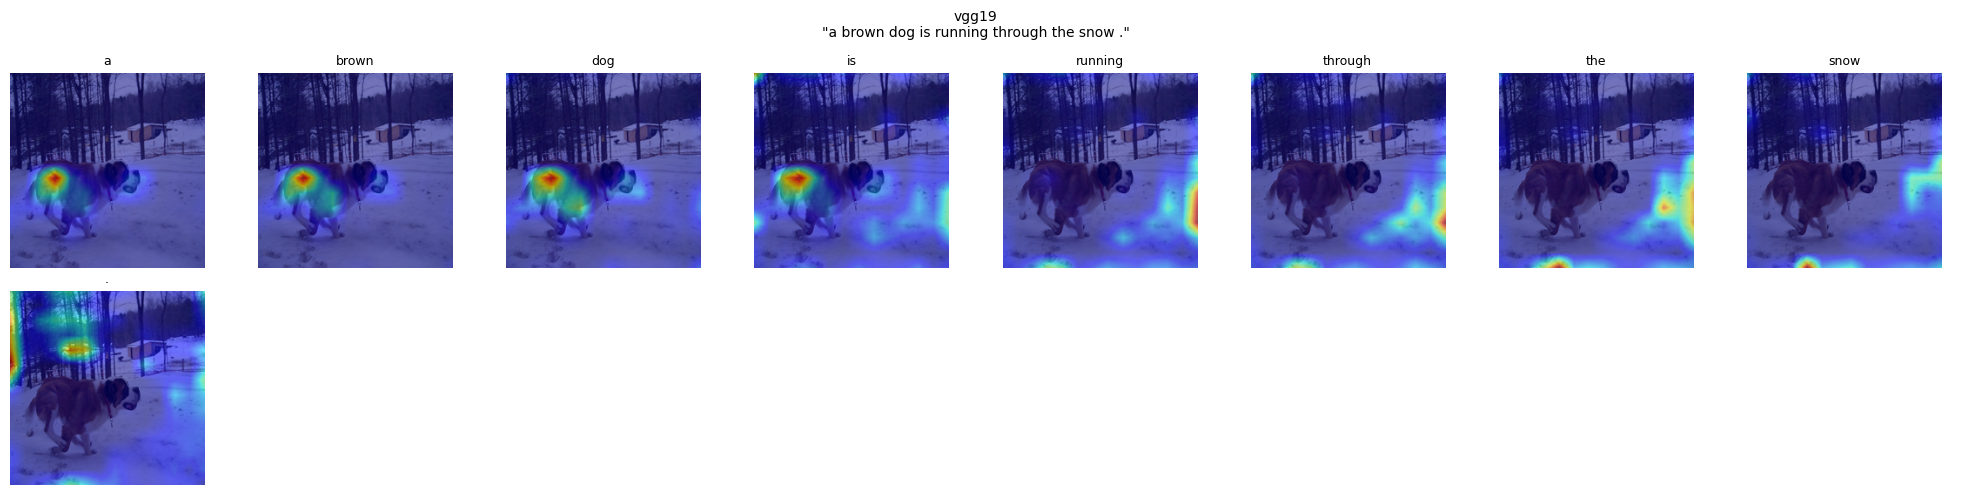

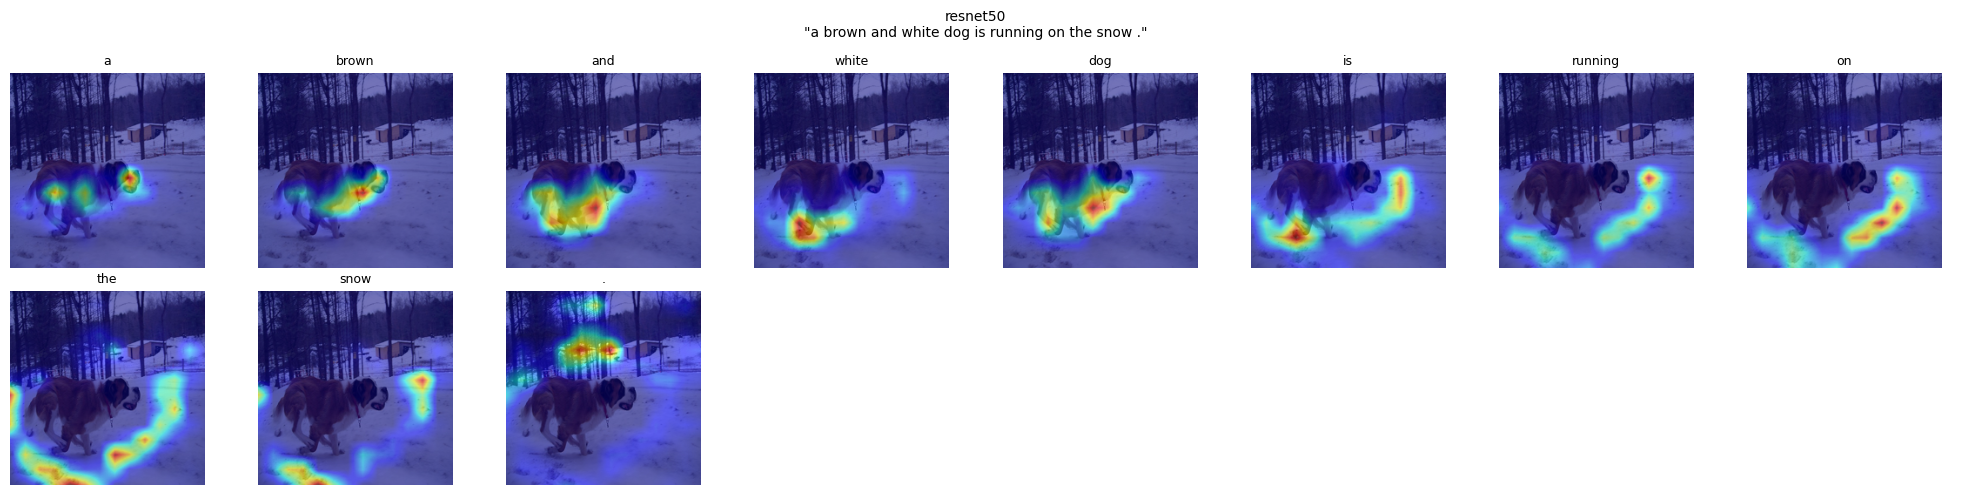

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] CLIPVisionModel LOAD REPORT from: openai/clip-vit-base-patch16
Key                                                          | Status     |  | 
-------------------------------------------------------------+------------+--+-
text_model.encoder.layers.{0...11}.layer_norm1.weight        | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.q_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.k_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc2.weight            | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc2.bias              | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc1.bias              | UNEXPECTED |  | 
text_model.final_layer_norm.bias                             | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.out_proj.bias   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.q_proj.weight   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_n

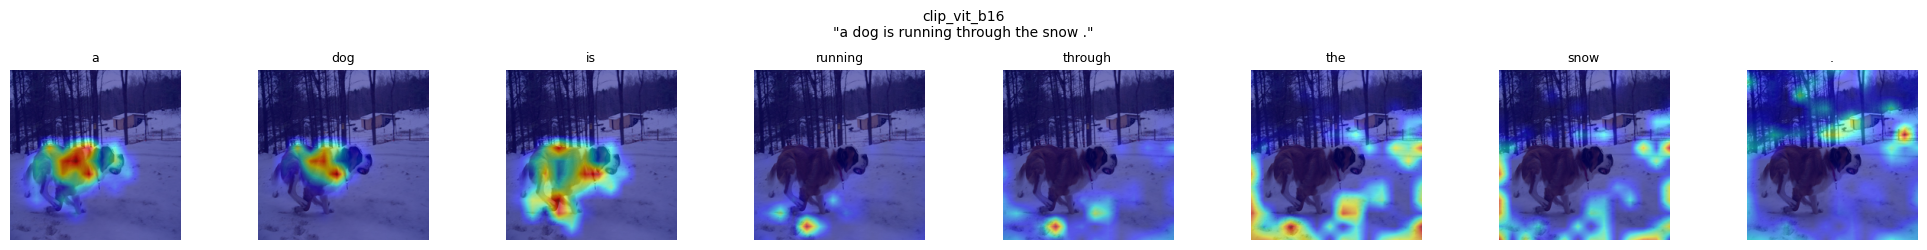

In [5]:
# Pick a random test image
_, test_tf_vgg = get_transforms('vgg19')
test_ds = AnnotationDataset('data/flicker8k', split_type='test',
                             vocab=vocab, transforms=test_tf_vgg, max_length=30)
unique_paths = list(dict.fromkeys(test_ds.img_paths))
img_path = random.choice(unique_paths)
print('Image:', img_path)
refs = test_ds.get_all_captions_for_image(img_path)
print('References:')
for r in refs: print(' ', r)

for enc_name in ['vgg19', 'resnet50', 'clip_vit_b16']:
    m, tf = load_model(enc_name)
    if m is not None:
        visualise_attention(img_path, m, tf, title=enc_name)